In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [16]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [17]:
cancer_data = load_breast_cancer()

In [18]:
X, y = cancer_data.data, cancer_data.target

In [19]:
target_names = cancer_data.target_names

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
scaler = StandardScaler()

In [22]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [24]:
model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [25]:
accuracy = model.score(X_test_scaled, y_test)
print(f"Accuracy: {accuracy:.4f}\n")

Accuracy: 0.9649



In [26]:
print("Classification Report:")
predictions = model.predict(X_test_scaled)
print(classification_report(y_test, predictions, target_names=target_names))

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



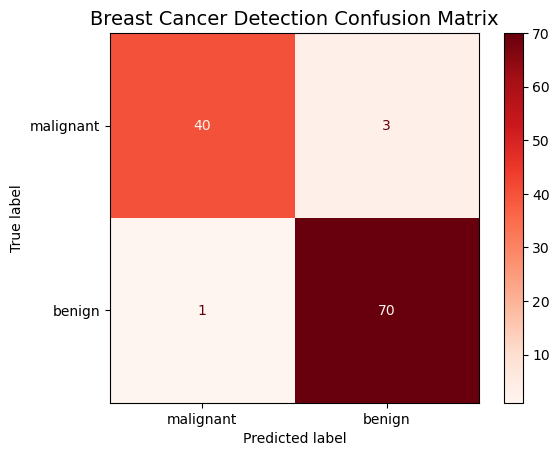

In [27]:
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test,
    display_labels=target_names,
    cmap=plt.cm.Reds
)
plt.title("Breast Cancer Detection Confusion Matrix", fontsize=14)
plt.show()